<a href="https://colab.research.google.com/github/RonGopal/intro_to_AI/blob/main/Assignment14rrg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install fairlearn
%pip install lime
import pandas as pd
import matplotlib.pyplot as plt
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=f7228d69c745be54bc600eb0fcac08d169ee8a30cc7beaf5b72a287e55bb62c1
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [3]:
df = pd.read_csv("Employers_data.csv")

df.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


In [4]:
# Sensitive attribute
sensitive = df["Gender"]

# Target variable
y = df["Salary"]

# Feature selection
X = df.drop(columns=["Salary"])

In [5]:
# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X, y, sensitive, test_size=0.3, random_state=42
)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [7]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.215
[[ 0  0  2 ...  0  0  0]
 [ 0  0 31 ...  0  0  0]
 [ 0  0 67 ...  0  0  0]
 ...
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]
              precision    recall  f1-score   support

       25000       0.00      0.00      0.00         2
       30000       0.00      0.00      0.00        35
       35000       0.45      0.83      0.58        81
       40000       0.30      0.14      0.19        49
       45000       0.00      0.00      0.00         9
       50000       0.00      0.00      0.00         1
       55000       0.00      0.00      0.00        13
       60000       0.00      0.00      0.00        87
       65000       0.31      0.58      0.40       232
       70000       0.28      0.47      0.35       253
       75000       0.16      0.02      0.03       172
       80000       0.00      0.00      0.00        92
       85000       0.00      0.00      0.00        48
       90000       0.20      0.15      0.17        55
       95000     

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
metrics = {
    "selection_rate": selection_rate,
    "false_positive_rate": false_positive_rate,
    "true_positive_rate": true_positive_rate
}

# Define a threshold for 'favorable' salary outcome
salary_threshold = 100000

y_true_binary = (y_test >= salary_threshold).astype(int)
y_pred_binary = (y_pred >= salary_threshold).astype(int)

mf = MetricFrame(
    metrics=metrics,
    y_true=y_true_binary,
    y_pred=y_pred_binary,
    sensitive_features=sensitive_test
)

print(mf.by_group)

        selection_rate  false_positive_rate  true_positive_rate
Gender                                                         
Female        0.504196             0.006780            0.853571
Male          0.528025             0.008251            0.854772


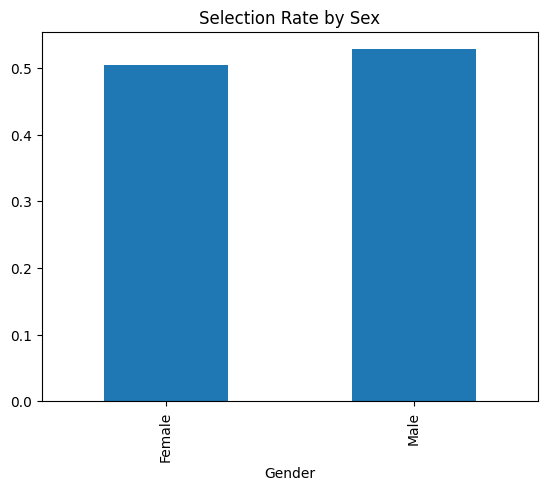

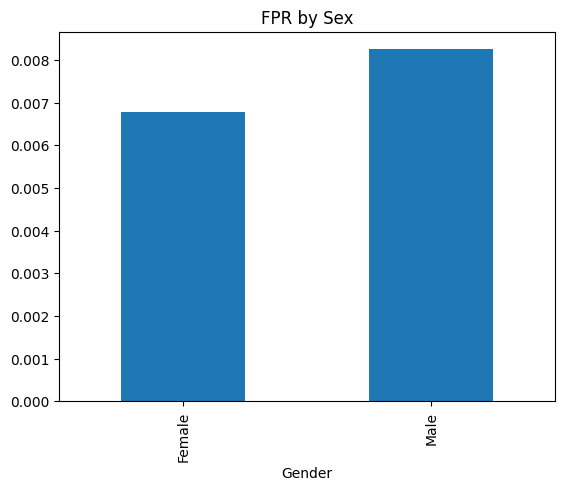

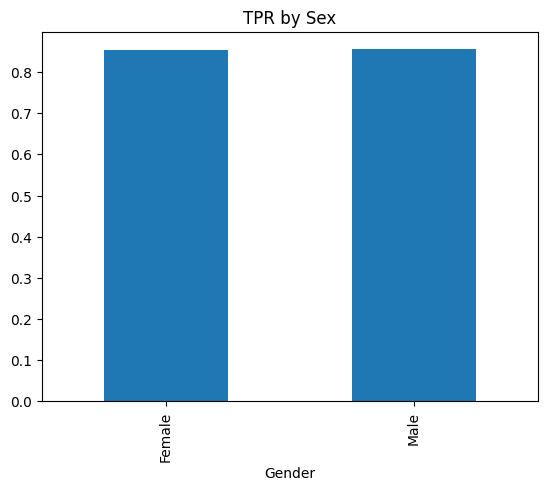

In [9]:
mf.by_group["selection_rate"].plot(kind="bar", title="Selection Rate by Sex")
plt.show()

mf.by_group["false_positive_rate"].plot(kind="bar", title="FPR by Sex")
plt.show()

mf.by_group["true_positive_rate"].plot(kind="bar", title="TPR by Sex")
plt.show()

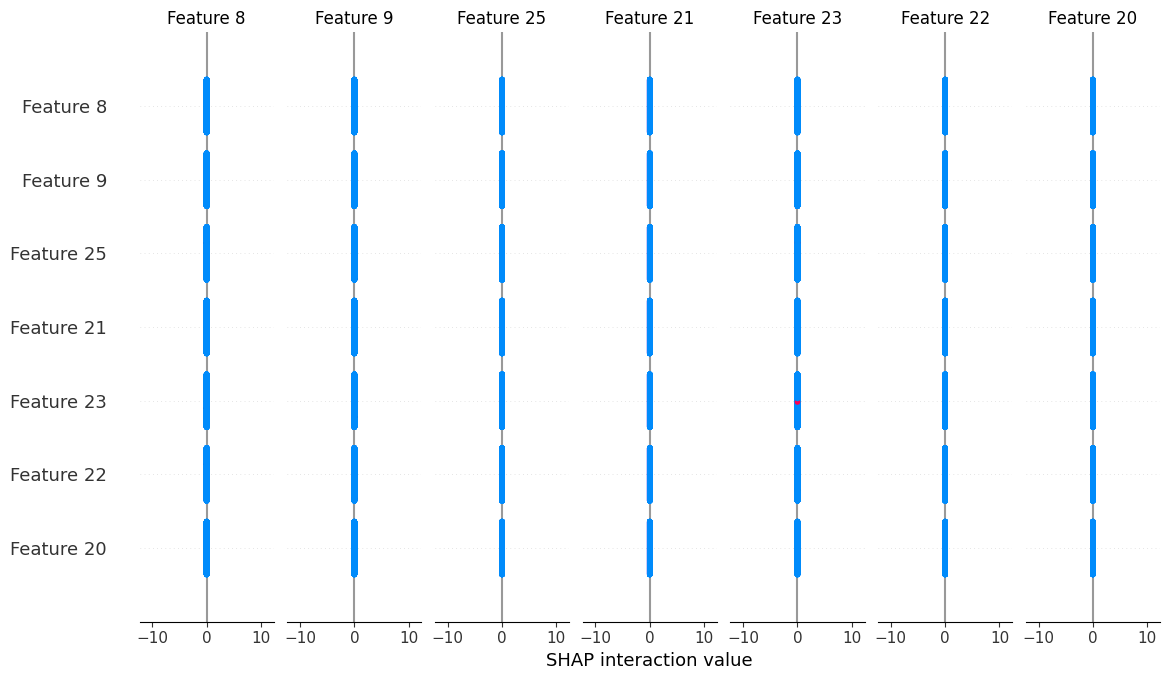

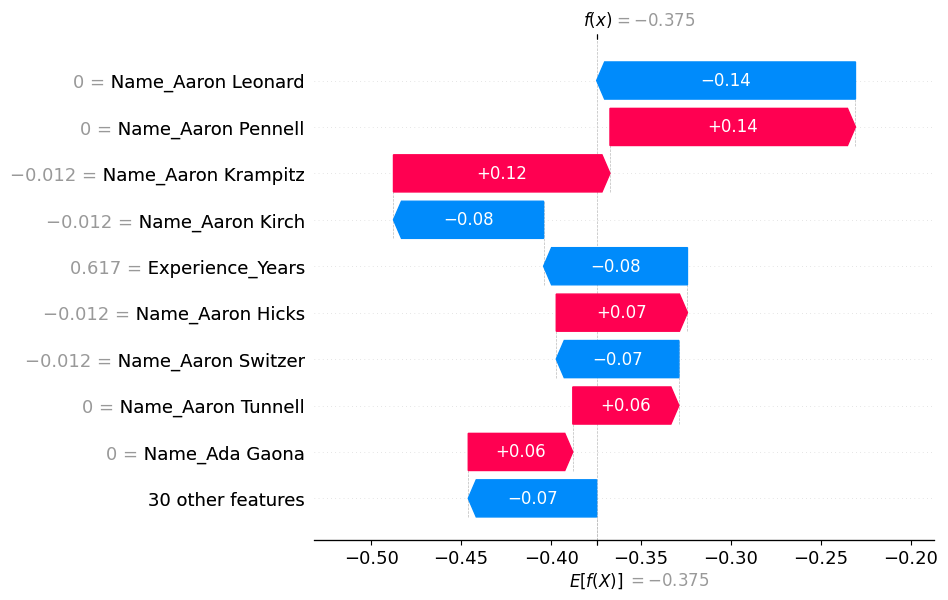

In [11]:
explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test)

# Global importance
shap.summary_plot(shap_values, X_test)

# Local explanation
# Assuming binary classification or we want to explain the first class's prediction
# and for the first instance in X_test
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0][0], # SHAP values for the first instance, first class
    base_values=explainer.expected_value[0], # Base value for the first class
    data=X_test[0], # Feature values for the first instance
    feature_names=X.columns # Feature names
))

In [12]:
lime_exp = LimeTabularExplainer(
    training_data=X_train,
    feature_names=X.columns,
    class_names=["<=50K", ">50K"],
    mode="classification"
)

exp = lime_exp.explain_instance(X_test[0], model.predict_proba)
exp.show_in_notebook()